### Accessing and Querying Diffsky data

The [OpenCosmo Toolkit](opencosmo.readthedocs.io) allows you to access, query, and analyze `diffsky` data at scale, even when working with limited resources. This tutorial notebook covers a few topics:

1. How to open the mock catalog
2. How to restrict the catalog to specific redshift range
3. How to perform basic cuts (e.g. on stellar mass)
4. How to add additional columns to the catalog


<div class="meta-block">
  <div class="meta-row">
    <span class="meta-label">Data</span>
    <span class="chip chip-data">Diffsky Galaxies</span>
  </div>

  <div class="meta-row">
    <span class="meta-label">Tasks</span>
    <span class="chip chip-task">Query</span>
    <span class="chip chip-task">Select</span>
    <span class="chip chip-task">Filter</span>
    <span class="chip chip-task">Add Columns</span>
    <span class="chip chip-task">Evaluate</span>

  </div>
</div>




The specific examples we use in notebook may not be relevant to your science, but the techniques we use can be used for any science problem. 

`opencosmo` is capable of supporting advanced workflows, including when running in parallel. For more details, see [the docs](opencosmo.readthedocs.io).


### 1. Accessing the Data on Perlmutter

There are a large number of mock catalogs available, for this tutorial we will use one calibrated against cosmos. To open the data, we simply find all the catalog files and pass them to `opencosmo`. There are also a few files in the folder that contain metadata, so we filter out those files before passing them to the toolkit.

This can take some time. This is not a result of data actually being read. Instead, OpenCosmo has to examine all the files to make sure they are formatted correctly. This can be a bit slow on supercomputer filesystems, but should hopefully not be too painful.

**Pro tip:** You can access descriptions of the various columns with `ds.descriptions` and the underlying cosmology with `ds.cosmology`

In [1]:
from pathlib import Path
import opencosmo as oc
import matplotlib.pyplot as plt
import numpy as np

In [2]:
data_path = Path("/global/cfs/cdirs/hacc/OpenCosmo/LastJourney/synthetic_galaxies/hltds_cosmos_260215_02_17_2026")
files = [p for p in data_path.glob("*.hdf5") if "diffsky_gals" in p.stem]
ds = oc.open(files)

### 2. Selecting a Subset

`ds` is an opencosmo [Lightcone](https://opencosmo.readthedocs.io/en/stable/collection_ref.html) object. It doesn't yet contain any data. If we requested data right now, it would try to load all ~400GB of the catalog's data into memory at once, which wastes a significant amount of time and will likely cause your process to crash. Instead, we want to use the toolkit to select the specific data we want to work with for our analysis.

For example. Let's make a **plot of stellar vs. halo mass** for **central galaxies** with a stellar mass above $10^{11}$

a. **Restrict to a redshift range:** If you need to work with objects in a specific redshift range, it is good practice to select that redshift range first. This will generally make downstream operations (particularly filters) faster.

In [6]:
ds_shmr = ds.with_redshift_range(0.5, 0.6)

Notice that we are assigning the result of `with_redshift_range` to a new variable, `ds_shmr`. Operations in `opencosmo` do not modify their datasets. Instead, they return new datasets with the operation performed. Because `opencosmo` has not actually loaded any data into memory, it costs us nothing to keep the original `ds` object around. We can always come back later if we want to start again.

b. **Selecting centrals and making mass cuts.**

The catalog has a column called `central` which has a value of 1 for central galaxies. We also want to filter out any objects with a stellar mass (column name `logsm_obs`) less than $10^{11}%$. 

To do this in `opencosmo` we use `oc.col()` to construct the filters and then `ds.filter` to apply them.

In [7]:
is_central = oc.col("central") == 1
high_mass_cut = oc.col("logsm_obs") > 11
ds_shmr = ds_shmr.filter(is_central, high_mass_cut)

c. **Selecting only relevant columns and getting the data**

The catalog contains around 100 columns, but we only need two for this plot. Selecting only these two will significantly decrease the amount of data we need to read and speed up our query.

Once we've selected these columns, we can get the data by calling `ds_shmr.get_data()`. The default output format is an astropy table with units. In this case, let's just get the results as numpy arrays.

In [12]:
ds_shmr = ds_shmr.select(("logsm_obs", "logmp_obs"))
shmr_data = ds_shmr.get_data("numpy")
shmr_data

{'logmp_obs': array([12.36594122, 13.42772046, 13.1565465 , ..., 13.19589612,
        12.32141763, 13.10084836], shape=(20108,)),
 'logsm_obs': array([11.08743827, 11.43487487, 11.39180886, ..., 11.37543998,
        11.0702923 , 11.40117351], shape=(20108,))}

### 3. Plot it Up
Now we can just use `matplotlib` to look at the relationship. As we expect, there is a hard cutoff at stellar masses < $10^{11}$

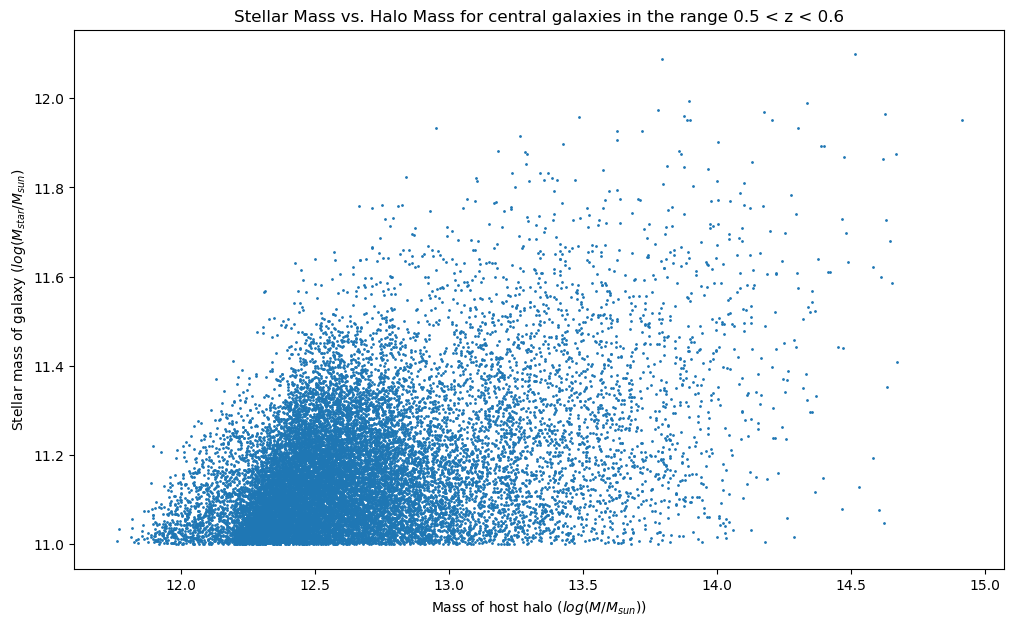

In [15]:
plt.figure(figsize=(12,7))
plt.scatter(shmr_data["logmp_obs"], shmr_data["logsm_obs"], s = 1)
plt.xlabel("Mass of host halo ($log(M / M_{sun})$)")
plt.ylabel("Stellar mass of galaxy ($log(M_{star} / M_{sun}$)")
_ = plt.title("Stellar Mass vs. Halo Mass for central galaxies in the range 0.5 < z < 0.6")

# Computing the Star Formation Rate
The catalogs have a column constaining the log of the stellar mass, and a column containing the log of the *specific* star formation rate (the total mass of stars being formed in the galaxy divided by its stellar mass). We can combine these to get the log of the absolute star formation rate by simply adding the columns together.

In [3]:
log_sfr = oc.col("logssfr_obs") + oc.col("logsm_obs")
ds = ds.with_new_columns(log_sfr=log_sfr)

Note we are adding the columns to the original dataset we loaded, which knows about all the data in our catalog. Because `opencosmo` is [lazy](https://en.wikipedia.org/wiki/Lazy_evaluation),  calling `with_new_columns` in this way does not compute any values. The values for the new `log_sfr` column will only be computed when we request data down the line.

You can combine columns like the example above in a whole host of interesting ways, including multiplication, exponentiation, and more. For details, see [this example](https://opencosmo.readthedocs.io/en/stable/cols.html#adding-custom-columns) in the OpenCosmo docs, as well as the [API docs](https://opencosmo.readthedocs.io/en/stable/column_ref.html) for more details.

Let's look at a histogram of the log of the star formation rate for central galaxies in a relatively narrow mass bin.

In [8]:
mass_cut = (oc.col("logsm_obs") > 11.5) & (oc.col("logsm_obs") < 11.7)

ds_sfr = ds.with_redshift_range(1, 1.2)
ds_sfr = ds_sfr.filter(is_central, mass_cut)
sfr_data = ds_sfr.select("log_sfr").get_data()

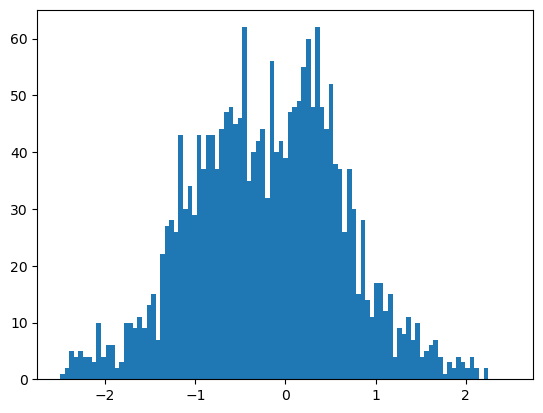

In [9]:
import numpy as np
_ = plt.hist(sfr_data.value, bins=np.linspace(-2.5, 2.5, 100))

## Computing Cosmological Distances Angular Sizes

Computing angular sizes is a more subtle challenge. The example above shows us how to create new columns out of algebraic combinations of existing columns. But to compute an angular size we need an angular diameter distance. which is not included in our columns. Let's compute it, the luminosity distances, and the angular sizes of the galaxy disks. 

In [10]:
import astropy.units as u

def distances_and_angular_size(r50_disk, redshift_true, cosmology):
    dA = cosmology.angular_diameter_distance(redshift_true)
    dL = cosmology.luminosity_distance(redshift_true)
    angular_size = r50_disk.to(u.Mpc) / dA
    return {
        "dA": dA,
        "dL": dL,
        "angular_size_disk": angular_size * u.rad
    }

ds = ds.evaluate(distances_and_angular_size, cosmology = ds.cosmology, vectorize=True)

There are three key pieces to making sure this call to `evaluate` works properly:
1. `r50_disk` and `redshift_true` are the names of actual columns in the dataset. `opencosmo` looks at the names of the arguments in the functions you create to determine which columns it needs to pass to your function.
2. `cosmology` is not a column in the dataset, instead it is the `astropy` cosmology object we use to do the cosmological calculations. We pass it in as a keyword argument to `ds.evaluate`. If we don't pass it in, `opencosmo` will complain to us.
3. We set the `vectorize = True` flag to make sure that `opencosmo` performs the calculation across all the rows at the same time. Otherwise it will go row-by-row, which will be multiple orders of magnitude slower.

You can use `evalute` to do complex computations that produce many columns. For more information, see the [evaluate documentation](https://opencosmo.readthedocs.io/en/stable/evaluating.html#evaluating-on-lightcones-and-simulation-collections).

In [11]:
mass_filter_low = oc.col("logsm_obs") > 10
mass_filter_high = oc.col("logsm_obs") < 10.5
ds_theta = ds.with_redshift_range(1, 1.1)
ds_theta = ds.filter(mass_filter_low, mass_filter_high)
ds_theta = ds_theta.select(("angular_size_disk", "logsm_obs"))


In [12]:
size_data = ds_theta.get_data("numpy")

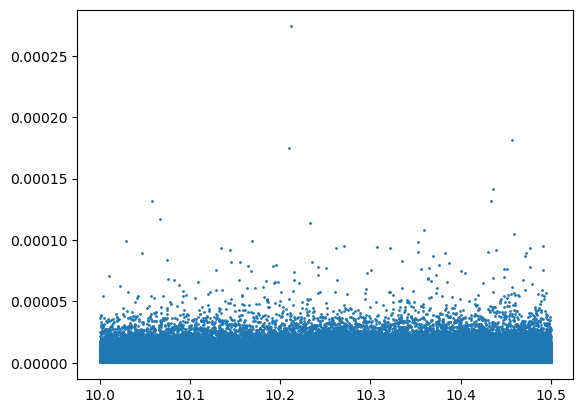

In [13]:
plt.scatter(size_data["logsm_obs"], size_data["angular_size_disk"], s = 1)
